<center>
<h2> </h2>
<h2>ALTeGraD 2024<br>Lab Session 2: Transfer learning for NLP</h2> 15 / 10 / 2024<br> Dr. G. Shang, Y.Zhang<br><br>


<b>Student name:</b> Antoine Peyronnet

</center>

<br><br>
In this lab we will:
* Implement and pretrain a language model with transformer architecture.
* Use the pretrained model (transfer learning) to perform a sentiment analysis task which consists of classifying some books reviews into positive and negative ones.
* Compare the performance of the pretrained model to a model trained from scratch.
 <br>

<b>The deadline for this lab is October 22, 2024 11:59 PM.</b> More details about the submission and the architecture for this lab can be found in the handout PDF.

In [2]:
import math

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### The Model

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, nhid, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, nhid)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, nhid, 2).float() * (-math.log(10000.0) / nhid)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0), :]
        return self.dropout(x)

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, dropout=0.5):
        super(TransformerModel, self).__init__()
        '''
        ntokens: the size of vocabulary
        nhid: the hidden dimension of the model.
        We assume that embedding_dim = nhid
        nlayers: the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
        nhead: the number of heads in the multiheadattention models
        dropout: the dropout value
         '''
        self.model_type = "Transformer"

        self.encoder = nn.Embedding(ntoken, nhid) # fill me, nhid = the dim_embed
        self.pos_encoder = PositionalEncoding(nhid) #fill me
        encoder_layers = nn.TransformerEncoderLayer(nhid, nhead, nhid) #fill me we assume nhid = d_model = dim_feedforward
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=nlayers) #fill me
        self.nhid = nhid
        self.init_weights()

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = (
            mask.float()
            .masked_fill(mask == 0, float("-inf"))
            .masked_fill(mask == 1, float(0.0))
        )
        return mask

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src, src_mask):
        src = self.encoder(src) * math.sqrt(self.nhid)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)
        return output

class ClassificationHead(nn.Module):
    def __init__(self, nhid, nclasses):
        super(ClassificationHead, self).__init__()
        self.decoder = nn.Linear(nhid, nclasses)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        output = self.decoder(src)
        return output

class Model(nn.Module):
    def __init__(self, ntoken, nhead, nhid, nlayers, nclasses, dropout=0.5):
        super(Model, self).__init__()
        self.base = TransformerModel(ntoken, nhead, nhid, nlayers, dropout)
        self.classifier = ClassificationHead(nhid, nclasses)

    def forward(self, src, src_mask):
        # base model
        x = self.base(src, src_mask) #fill me
        # classifier model
        output = self.classifier(x) #fill me
        return output

Let's verify if our model works, by applying one inference step

In [5]:
ntokens = 100 # the size of vocabulary
nhid = 200  # hidden dimension
nlayers = 4  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 2  # the number of heads in the multiheadattention models
dropout = 0  # the dropout value

model = Model(ntokens, nhead, nhid, nlayers, ntokens, dropout).to(device)
dummy_input = torch.tensor([[2, 6, 2, 5, 43, 21]]).to(device)
src_mask = model.base.generate_square_subsequent_mask(1).to(device)
out = model.forward(dummy_input, src_mask)

print(out.shape) # is it the right shape?

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


torch.Size([1, 6, 100])


## Vocabulary and Tokenization

In [6]:
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/dict.txt
!head -5 dict.txt

--2024-10-22 16:46:42--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/dict.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 577587 (564K) [text/plain]
Saving to: ‘dict.txt’

dict.txt            100%[===================>] 564.05K  --.-KB/s    in 0.008s  

2024-10-22 16:46:42 (66.1 MB/s) - ‘dict.txt’ saved [577587/577587]

▁d 1
es 1
▁l 1
en 1
on 1


Remark: in what follows: the token2ind gives the first 4 places to those special tokens: "<sos>": 0, "<pad>": 1, "<eos>": 2, "<oov>": 3
So we need to be careful in the indexes that follows:
since we are giving an indice to the written token, we need to 

Two options are possible 

1. we could just do 
`token2ind[word] = idx+4`
2. the one I find personally better and elegant is to work directly on the `enumerate`: `for idx, line in enumerate(f, start=4)`
We reserve the index 0 to 3 for the special tokens. and start counting at 4. 

In [7]:
path_vocab = "dict.txt"
token2ind = {"<sos>": 0, "<pad>": 1, "<eos>": 2, "<oov>": 3} # the 4 first indices are reserved to special tokens
with open(path_vocab, "r") as f:
    for idx, line in enumerate(f):
        word = line.split()[0].strip()
        token2ind[word] = idx + 4

ind2token = {ind: tok for tok, ind in token2ind.items()}


print(ind2token[1111])

▁trop


We can check that the 4th index we find the first elements of our `.txt` file 



Actually let's detail some of the functions of the extra tokens 
1. `<sos>` is designed to inform a begining of a sentence etc...
2. `<eos>` the end 
3. `<oov>`is usually used for tokens that are not registered/ unknown --> we connect them to that token and state it's unknown 

So two things we need to make sure about when we want to convert our sequence into tokens:
1. First, be sure to start with `<sos>` and end with `<eos>`
2. Second, if a token is not recognised $\longrightarrow$ it's coded into the `<oov>` token 



### Data Loader


In [8]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset


class Dataset(Dataset):
    def __init__(
        self,
        path_documents,
        path_labels=None,
        token2ind={},
        max_len=512,
        task="language_modeling",
    ):
        self.task = task
        self.max_len = max_len
        self.token2ind = token2ind
        self.documents = []
        self.labels = []
        with open(path_documents, "r") as f1:
            for line in f1:
                self.documents.append(line.strip())
        if task == "classification":
            with open(path_labels, "r") as f1:
                for line in f1:
                    self.labels.append(int(line.strip()))
            assert len(self.labels) == len(self.documents)

    def __len__(self):
        return len(self.documents)

    def __getitem__(self, index):
        sequence = self.documents[index].split()
        if len(sequence) > self.max_len - 1:
            sequence = sequence[: self.max_len - 1]
        #fill me (constract the input sequence using token2ind, sequence and special tokens)
        source_sequence = [self.token2ind["<sos>"]] + [self.token2ind.get(word, self.token2ind["<oov>"]) for word in sequence] + [self.token2ind["<eos>"]]
        if self.task == "language_modeling":
            target = source_sequence[1:]
            target.append(self.token2ind["<eos>"])
        elif self.task == "classification":
            target = [self.labels[index]]
        sample = {
            "source_sequence": torch.tensor(source_sequence),
            "target": torch.tensor(target),
        }
        return sample


def MyCollator(batch):
    source_sequences = pad_sequence(
        #we use padding to match the length of the sequences in the same batch
        [sample["source_sequence"] for sample in batch], padding_value=token2ind["<pad>"]
    )
    target = pad_sequence(
        [sample["target"] for sample in batch], padding_value=token2ind["<pad>"]
    )
    return source_sequences, target.reshape(-1)


def get_loader(
    path_documents,
    path_labels=None,
    token2ind={},
    max_len=512,
    batch_size=32,
    task="language_modeling",
):
    dataset = Dataset(
        path_documents,
        path_labels=path_labels,
        token2ind=token2ind,
        max_len=512,
        task=task,
    )
    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=MyCollator,
        pin_memory=True,
        drop_last=True,
    )
    return data_loader

## The Training

In [9]:
def train(
    path_data_train,
    path_labels_train=None,
    path_data_valid=None,
    save_interval=-1,
    log_interval=5,
    task="language_modeling",
    batch_size=32,
):
    model.train()
    total_loss = 0.0
    ntokens = len(token2ind)
    data_loader = get_loader(
        path_data_train,
        path_labels_train,
        token2ind,
        task=task,
        batch_size=batch_size,
    )

    losses = []
    for idx, data in enumerate(data_loader): #step 1
        optimizer.zero_grad()
        src_mask = model.base.generate_square_subsequent_mask(data[0].size(0)).to(
            device
        )
        input = data[0].to(device)
        output = model(input, src_mask) #step 2
        if task == 'classification':
            #last vector only

            output = output[-1]
        output = output.view(-1, output.shape[-1])
        target = data[1]
        target = target.to(device)
        loss =  criterion(output, target)
        #fill me step 3
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5) # prevent exploding gradient
        #fill me step 4

        optimizer.step()

        total_loss += loss.item()
        if idx % log_interval == 0 and idx > 0:
            cur_loss = total_loss / log_interval
            print(
                "| epoch {:3d} | {:5d}/{:5d} steps | "
                "loss {:5.5f} | ppl {:8.3f}".format(
                    epoch, idx, len(data_loader), cur_loss, math.exp(cur_loss),
                )
            )
            losses.append(cur_loss)
            total_loss = 0
    return losses

In [10]:
ntokens = len(token2ind)
nhid = 200  # the dimension of the feedforward network model in nn.TransformerEncoder
nlayers = 4  # the number of nn.TransformerEncoderLayer in nn.TransformerEncoder
nhead = 2  # the number of heads in the multiheadattention models
dropout = 0  # the dropout value

nclasses = 2 # for classification task only

model = Model(ntokens, nhead, nhid, nlayers, ntokens, dropout).to(device)

In [11]:
# optimization paramerters

criterion = nn.CrossEntropyLoss(ignore_index=token2ind['<pad>'])
lr = 0.0003  # learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [12]:
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretraining_subset.txt
path_data_train = "pretraining_subset.txt"

--2024-10-22 16:47:10--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretraining_subset.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10146460 (9.7M) [text/plain]
Saving to: ‘pretraining_subset.txt’

pretraining_subset. 100%[===================>]   9.68M  --.-KB/s    in 0.04s   

2024-10-22 16:47:10 (243 MB/s) - ‘pretraining_subset.txt’ saved [10146460/10146460]



In [13]:
#pretraining on a tiny subset
log_interval = 500
epochs = 20
for epoch in range(1, epochs + 1): #5
    train(
        path_data_train,
        save_interval=-1,
        task="language_modeling", # fill me
        batch_size=16,
        log_interval=log_interval,
    )

| epoch   1 |   500/ 3125 steps | loss 7.13710 | ppl 1257.777
| epoch   1 |  1000/ 3125 steps | loss 6.37058 | ppl  584.396
| epoch   1 |  1500/ 3125 steps | loss 6.09472 | ppl  443.508
| epoch   1 |  2000/ 3125 steps | loss 5.92790 | ppl  375.365
| epoch   1 |  2500/ 3125 steps | loss 5.82750 | ppl  339.508
| epoch   1 |  3000/ 3125 steps | loss 5.74852 | ppl  313.726
| epoch   2 |   500/ 3125 steps | loss 5.46197 | ppl  235.560
| epoch   2 |  1000/ 3125 steps | loss 5.42841 | ppl  227.787
| epoch   2 |  1500/ 3125 steps | loss 5.40931 | ppl  223.477
| epoch   2 |  2000/ 3125 steps | loss 5.36341 | ppl  213.451
| epoch   2 |  2500/ 3125 steps | loss 5.32991 | ppl  206.419
| epoch   2 |  3000/ 3125 steps | loss 5.29992 | ppl  200.321
| epoch   3 |   500/ 3125 steps | loss 5.03143 | ppl  153.152
| epoch   3 |  1000/ 3125 steps | loss 5.01253 | ppl  150.284
| epoch   3 |  1500/ 3125 steps | loss 5.01855 | ppl  151.192
| epoch   3 |  2000/ 3125 steps | loss 5.01741 | ppl  151.020
| epoch 

## Text Generation


In [14]:
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretrained_model_4layers.pt

model = Model(ntokens, nhead, nhid, nlayers, ntokens).to(device)

#load the checkpoint
checkpoint = torch.load('pretrained_model_4layers.pt')
#load state dict
model.load_state_dict(checkpoint['model_state_dict'])

--2024-10-22 17:35:53--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/pretrained_model_4layers.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88093955 (84M) [application/octet-stream]
Saving to: ‘pretrained_model_4layers.pt’

pretrained_model_4l 100%[===================>]  84.01M   416MB/s    in 0.2s    

2024-10-22 17:35:54 (416 MB/s) - ‘pretrained_model_4layers.pt’ saved [88093955/88093955]



/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
<ipython-input-14-76a40ce8b80e>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

<All keys matched successfully>

In [15]:
# !pip install sentencepiece   # uncomment this if you are using google colab
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/sentencepiece.french.model

import sentencepiece as spm

s = spm.SentencePieceProcessor(model_file='sentencepiece.french.model') #load sentencepiece model

#examples
encoded = s.encode_as_pieces("Bonjour les amis!")
decoded = s.decode_pieces(encoded)
print(encoded)
print(decoded)

--2024-10-22 17:42:08--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/sentencepiece.french.model
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115362 (1.1M) [application/octet-stream]
Saving to: ‘sentencepiece.french.model’

sentencepiece.frenc 100%[===================>]   1.06M  --.-KB/s    in 0.007s  

2024-10-22 17:42:08 (151 MB/s) - ‘sentencepiece.french.model’ saved [1115362/1115362]

['▁Bonjour', '▁les', '▁amis', '!']
Bonjour les amis!


In [16]:
def infer_next_token(sent):
    model.eval()
    sent_pieces = s.encode_as_pieces(sent)
    source = [token2ind['<sos>']] + [token2ind[el] for el in sent_pieces] # list of tokens
    source = torch.tensor(source).to(device)
    source = source.reshape(-1, 1)
    src_mask = model.base.generate_square_subsequent_mask(source.size(0)).to(device)
    out = model(source, src_mask)
     #fill me
    next_token_ind = torch.argmax(out[-1, 0]).item()
    return next_token_ind, out

# Task 5 Implement the function infer next tokens() that takes as input a string sent and an
# inte- ger max len and returns a completion of the input sentence. The generation should stop
# when the model generates <eos> or the length of the generated sentence reaches max len

def infer_next_tokens(sent, max_len=50):
    # to be implemented
    model.eval()
    sent_pieces = s.encode_as_pieces(sent)
    source = [token2ind['<sos>']] + [token2ind[el] for el in sent_pieces] # list of tokens
    source = torch.tensor(source).to(device)
    source = source.reshape(-1, 1)
    src_mask = model.base.generate_square_subsequent_mask(source.size(0)).to(device)
    out = model(source, src_mask)
    generated = []
    for _ in range(max_len):
        next_token_ind = torch.argmax(out[-1, 0]).item()
        if next_token_ind == token2ind['<eos>']:
            break
        generated.append(ind2token[next_token_ind])
        source = torch.cat([source, torch.tensor([[next_token_ind]]).to(device)])
        src_mask = model.base.generate_square_subsequent_mask(source.size(0)).to(device)
        out = model(source, src_mask)
    return s.decode_pieces(generated)

In [17]:
sent = "Bonjour les"
print(sent)
infer_next_tokens(sent)


Bonjour les


'gens qui ont été très accueillants et sympathiques.'

### Supervised task

In [36]:
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.review.spm
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.label
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/test.review.spm
!wget https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/test.label

path_data_train = "train.review.spm"
path_labels_train = "train.label"

path_data_valid = "test.review.spm"
path_labels_valid = "test.label"

--2024-10-22 14:45:43--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.review.spm
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1495960 (1.4M) [text/plain]
Saving to: ‘train.review.spm’

train.review.spm    100%[===================>]   1.43M  --.-KB/s    in 0.008s  

2024-10-22 14:45:43 (168 MB/s) - ‘train.review.spm’ saved [1495960/1495960]

--2024-10-22 14:45:43--  https://raw.githubusercontent.com/moussaKam/transfer_learning_transformers/main/cls-books/train.label
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, 

In [37]:
# a function to evaluate the validation accuracy of the model.
def evaluate_accuracy(data_loader):

    #to be implemented
    model.eval()
    correct = 0
    total = 0

    for idx, data in enumerate(data_loader):
        src_mask = model.base.generate_square_subsequent_mask(data[0].size(0)).to(device)
        input = data[0].to(device)
        output = model(input, src_mask)
        output = output[-1]
        output = output.view(-1, output.shape[-1])
        target = data[1]
        target = target.to(device)
        _, predicted = torch.max(output, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    return correct / total


In [38]:
#save the base model to be loaded later in the fine-tuning phase
torch.save({"model_state_dict": model.base.state_dict(),}, "pretrained_model_4layers_no_class_head.pt")

In [41]:
from_scratch_settings = [True, False]

from_scratch_valid_acc = []
pretrained_valid_acc = []
lr = 0.0001

for from_scratch in from_scratch_settings:
    model = Model(ntokens, nhead, nhid, nlayers, 2, dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if not from_scratch:
        print("=====PRETRAINED MODEL======")
        #load checkpoint
        checkpoint = torch.load("pretrained_model_4layers_no_class_head.pt")
        #load state dict
        model.base.load_state_dict(checkpoint['model_state_dict'])
    else:
        print("=====Trainig FROM SCRATCH======")
    epochs = 15
    for epoch in range(1, epochs + 1):
        train(
            path_data_train,
            path_labels_train,
            save_interval=-1,
            task='classification',
            batch_size=8,
            log_interval=50,
        )
        acc = evaluate_accuracy(
            get_loader(
                path_data_valid,
                path_labels_valid,
                token2ind=token2ind,
                batch_size=20,
                task='classification',
            )
        )
        if from_scratch:
            from_scratch_valid_acc.append(acc)
        else:
            pretrained_valid_acc.append(acc)
    print()

=====Trainig FROM SCRATCH======
| epoch   1 |    50/  200 steps | loss 0.81372 | ppl    2.256
| epoch   1 |   100/  200 steps | loss 0.71381 | ppl    2.042
| epoch   1 |   150/  200 steps | loss 0.71871 | ppl    2.052
| epoch   2 |    50/  200 steps | loss 0.64356 | ppl    1.903
| epoch   2 |   100/  200 steps | loss 0.61491 | ppl    1.849
| epoch   2 |   150/  200 steps | loss 0.56184 | ppl    1.754
| epoch   3 |    50/  200 steps | loss 0.54673 | ppl    1.728
| epoch   3 |   100/  200 steps | loss 0.41531 | ppl    1.515
| epoch   3 |   150/  200 steps | loss 0.42326 | ppl    1.527
| epoch   4 |    50/  200 steps | loss 0.22803 | ppl    1.256
| epoch   4 |   100/  200 steps | loss 0.21895 | ppl    1.245
| epoch   4 |   150/  200 steps | loss 0.21630 | ppl    1.241
| epoch   5 |    50/  200 steps | loss 0.03599 | ppl    1.037
| epoch   5 |   100/  200 steps | loss 0.12312 | ppl    1.131
| epoch   5 |   150/  200 steps | loss 0.10986 | ppl    1.116
| epoch   6 |    50/  200 steps | loss

<ipython-input-41-f09076582a3e>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("pretrained_model_4layers_no_class_head.pt")


| epoch   1 |    50/  200 steps | loss 0.86279 | ppl    2.370
| epoch   1 |   100/  200 steps | loss 0.70517 | ppl    2.024
| epoch   1 |   150/  200 steps | loss 0.64037 | ppl    1.897
| epoch   2 |    50/  200 steps | loss 0.53644 | ppl    1.710
| epoch   2 |   100/  200 steps | loss 0.50710 | ppl    1.660
| epoch   2 |   150/  200 steps | loss 0.42063 | ppl    1.523
| epoch   3 |    50/  200 steps | loss 0.40735 | ppl    1.503
| epoch   3 |   100/  200 steps | loss 0.39081 | ppl    1.478
| epoch   3 |   150/  200 steps | loss 0.41140 | ppl    1.509
| epoch   4 |    50/  200 steps | loss 0.44401 | ppl    1.559
| epoch   4 |   100/  200 steps | loss 0.34226 | ppl    1.408
| epoch   4 |   150/  200 steps | loss 0.38602 | ppl    1.471
| epoch   5 |    50/  200 steps | loss 0.19736 | ppl    1.218
| epoch   5 |   100/  200 steps | loss 0.36979 | ppl    1.447
| epoch   5 |   150/  200 steps | loss 0.26392 | ppl    1.302
| epoch   6 |    50/  200 steps | loss 0.15689 | ppl    1.170
| epoch 

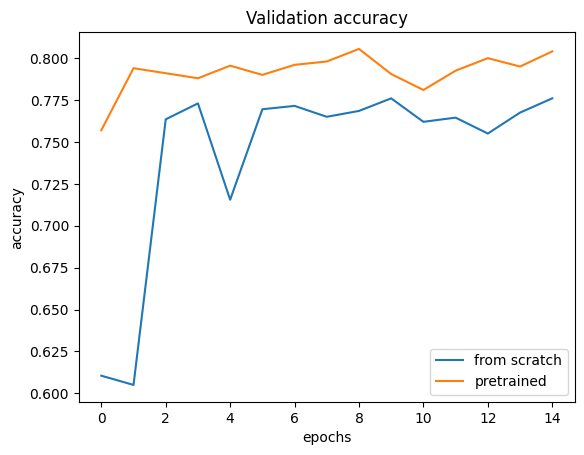

In [42]:
#Visualize the accuracy

#Visualize the accuracy
import matplotlib.pyplot as plt

plt.plot(from_scratch_valid_acc, label="from scratch")
plt.plot(pretrained_valid_acc, label="pretrained")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Validation accuracy")

plt.show()
